# FireSight-IR | Module 1a — VIIRS & FIRMS Cloud Ingestion (v3)

**Project:** FireSight-IR — Physics-constrained wildfire intelligence at constellation scale  
**Platform:** Google Colab (cloud-native, no local downloads)  
**Version:** v3.0 — post-run corrections from live audit output  

---

## Corrections from v2 → v3

| # | Issue | Root cause | Fix |
|---|---|---|---|
| A | 🔴 All paths `PATH NOT FOUND` → no fire pixels extracted | VNP14IMG v002 has NO `Fire Pixels/` group — all FP arrays live at HDF5 root as `/FP_*` | Removed `Fire Pixels/` prefix from all `CANDIDATE_PATHS` |
| B | 🔴 `with earthaccess.open(...) as fhs` fails | `earthaccess.open()` returns a plain list, not a context manager | Changed to `fhs = earthaccess.open(...)` pattern throughout |
| C | 🟡 Existing v1 parquets missing `datetime_utc` and `BTD_zscore` | Batch skips years where parquet exists — v1 files were never re-extracted | Added schema version check; prompts to delete stale files before re-run |
| D | 🟢 `Active days` counts negative `Skipped days` | `season_days` approximation (6 months × 30) < actual days in fire season | Fixed to count actual calendar days in fire season months |

---

## What this notebook does

1. **Mounts Google Drive** for persistent output storage across Colab sessions
2. **Downloads FIRMS** VIIRS S-NPP Standard Processing archives (2018–2023) via the FIRMS area API
3. **Runs a structure + fill-value audit** on one VNP14IMG v002 granule before batch extraction
4. **Streams VNP14IMG** Collection 2 granules from NASA Earthdata S3 — guided by FIRMS active-fire days
5. **Extracts fire pixel records** with correct HDF5 paths, fill masking, UTC timestamps, and derived features
6. **Verifies output quality** against expected statistics

> **Note:** 32×32 spatial patch extraction happens in Module 1c. This notebook produces the per-pixel tabular dataset that feeds Modules 1b (ERA5 co-location) and 2 (feature engineering).

---

## Before running
- **NASA Earthdata:** https://urs.earthdata.nasa.gov/users/new
- **FIRMS map key:** https://firms.modaps.eosdis.nasa.gov/api/map_key/

---
## Section 0 — Install packages and mount Drive

**Run this section at the start of every Colab session.**

In [9]:
!pip install earthaccess requests pandas numpy xarray h5py h5netcdf pyarrow tqdm -q
print("✓ Packages installed")

✓ Packages installed


In [10]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted at /content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted at /content/drive


In [11]:
import os
import time
import warnings
import requests
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import xarray as xr
import h5py
import earthaccess
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✓ Imports complete")

✓ Imports complete


---
## Section 1 — Project configuration

All parameters live here. **Do not hardcode values anywhere else.**

In [12]:
# ── Spatial domain — Western US ───────────────────────────────────────────────
BBOX_TUPLE = (-125, 32, -109, 49)               # (west, south, east, north) — earthaccess
BBOX_STR   = '-125,32,-109,49'                  # 'west,south,east,north'    — FIRMS API URL
BBOX_DICT  = {'lon_min': -125, 'lon_max': -109, 'lat_min': 32, 'lat_max': 49}
# CRITICAL: If you change one format, change all three.

# ── Temporal domain ───────────────────────────────────────────────────────────
TRAIN_YEARS        = [2018, 2019, 2020, 2021, 2022]
VAL_YEAR           = 2023
ALL_YEARS          = TRAIN_YEARS + [VAL_YEAR]
FIRE_SEASON_MONTHS = [5, 6, 7, 8, 9, 10]   # May–Oct

# ── Data sources ──────────────────────────────────────────────────────────────
FIRMS_SOURCE     = 'VIIRS_SNPP_SP'  # Standard Processing — do NOT use NRT
VIIRS_SHORT_NAME = 'VNP14IMG'
VIIRS_VERSION    = '002'

# ── Schema version — increment when output columns change ─────────────────────
# FIX C: parquets from v1/v2 are missing datetime_utc, BTD_zscore, granule_id.
# This version string is written into each parquet as metadata so the
# verification cell can detect stale files and prompt you to re-extract.
SCHEMA_VERSION = 'v3'

# ── FIRMS-guided download filter ──────────────────────────────────────────────
MIN_FIRMS_COUNT = 10

# ── Your FIRMS map key ────────────────────────────────────────────────────────
FIRMS_MAP_KEY = 'YOUR_FIRMS_MAP_KEY_HERE'  # <-- replace this

# ── Output paths on Google Drive ─────────────────────────────────────────────
DRIVE_ROOT  = Path('/content/drive/MyDrive/firesight-ir')
FIRMS_DIR   = DRIVE_ROOT / 'data/raw/firms'
VIIRS_DIR   = DRIVE_ROOT / 'data/processed/viirs_fp'
FIGURES_DIR = DRIVE_ROOT / 'figures'

for d in [FIRMS_DIR, VIIRS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✓ Configuration set")
print(f"  Training years : {TRAIN_YEARS}")
print(f"  Validation year: {VAL_YEAR}  (held out — do not use for training)")
print(f"  Bounding box   : {BBOX_STR}")
print(f"  VIIRS product  : {VIIRS_SHORT_NAME} v{VIIRS_VERSION}")
print(f"  Schema version : {SCHEMA_VERSION}")
print(f"  Drive root     : {DRIVE_ROOT}")

✓ Configuration set
  Training years : [2018, 2019, 2020, 2021, 2022]
  Validation year: 2023  (held out — do not use for training)
  Bounding box   : -125,32,-109,49
  VIIRS product  : VNP14IMG v002
  Schema version : v3
  Drive root     : /content/drive/MyDrive/firesight-ir


---
## Section 2 — NASA Earthdata authentication

**Run every session.**

In [13]:
auth = earthaccess.login(strategy='interactive')
assert auth.authenticated, "Authentication failed. Verify at https://urs.earthdata.nasa.gov"
print(f"✓ Authenticated as: {auth.username}")
print("✓ S3 direct access enabled — no files will be written to Colab disk")

✓ Authenticated as: Msledge7
✓ S3 direct access enabled — no files will be written to Colab disk


---
## Section 3 — FIRMS download

The FIRMS area API day range is capped at 5. The function loops in 5-day increments automatically.

In [14]:
FIRMS_BASE = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv'

def fetch_firms_year(
    year: int,
    map_key: str,
    source: str,
    bbox_str: str,
    bbox_dict: dict,
    fire_season_months: list,
    day_chunk: int = 5,
    retry_delay: float = 2.0,
    max_retries: int = 3,
) -> pd.DataFrame:
    """
    Download a full year of FIRMS fire detections for a bounding box.
    Loops in day_chunk-day windows (max 5, API limit).
    Filters to fire_season_months after concatenation.
    """
    assert day_chunk <= 5, "FIRMS API day_range cap is 5"

    chunks = pd.date_range(
        start=pd.Timestamp(f'{year}-01-01'),
        end=pd.Timestamp(f'{year}-12-31'),
        freq=f'{day_chunk}D'
    )

    frames = []
    failed_chunks = []

    for chunk_start in tqdm(chunks, desc=f'FIRMS {year}', unit='chunk', leave=False):
        date_str = chunk_start.strftime('%Y-%m-%d')
        url = f"{FIRMS_BASE}/{map_key}/{source}/{bbox_str}/{day_chunk}/{date_str}"

        for attempt in range(max_retries):
            try:
                resp = requests.get(url, timeout=30)
                if resp.status_code == 200 and len(resp.text.strip()) > 0:
                    df = pd.read_csv(StringIO(resp.text))
                    if len(df) > 0 and 'latitude' in df.columns:
                        frames.append(df)
                    break
                elif resp.status_code == 400:
                    break
                else:
                    if attempt < max_retries - 1:
                        time.sleep(retry_delay)
            except requests.RequestException:
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                else:
                    failed_chunks.append(date_str)

    if not frames:
        print(f"  [WARN] {year}: no data returned — check map key and source")
        return pd.DataFrame()

    result = pd.concat(frames, ignore_index=True)
    result['acq_date'] = pd.to_datetime(result['acq_date'])
    result['month']    = result['acq_date'].dt.month
    result = result[result['month'].isin(fire_season_months)].copy()
    result = result[
        (result['longitude'] >= bbox_dict['lon_min']) &
        (result['longitude'] <= bbox_dict['lon_max']) &
        (result['latitude']  >= bbox_dict['lat_min']) &
        (result['latitude']  <= bbox_dict['lat_max'])
    ].copy()

    if failed_chunks:
        print(f"  [WARN] {year}: {len(failed_chunks)} chunks failed: {failed_chunks[:5]}")

    return result


print("✓ fetch_firms_year() defined")

✓ fetch_firms_year() defined


In [15]:
assert FIRMS_MAP_KEY != 'f97281ae8847f65c02ab6b2c9ac60c13', "Set your FIRMS map key in Section 1"

firms_summary = {}

for year in ALL_YEARS:
    out_path = FIRMS_DIR / f'firms_viirs_snpp_{year}.parquet'

    if out_path.exists():
        df = pd.read_parquet(out_path)
        print(f"  {year}: {len(df):>9,} detections  [already on Drive — skipped]")
        firms_summary[year] = len(df)
        continue

    print(f"── {year} ──")
    df = fetch_firms_year(
        year=year, map_key=FIRMS_MAP_KEY, source=FIRMS_SOURCE,
        bbox_str=BBOX_STR, bbox_dict=BBOX_DICT,
        fire_season_months=FIRE_SEASON_MONTHS,
    )

    if len(df) > 0:
        df.to_parquet(out_path, index=False)
        print(f"  {year}: {len(df):>9,} detections saved → Drive")
        firms_summary[year] = len(df)
    else:
        print(f"  {year}: no data — check map key")
        firms_summary[year] = 0

print("\n✓ FIRMS download complete")

  2018:   197,013 detections  [already on Drive — skipped]
  2019:    62,576 detections  [already on Drive — skipped]
  2020:   358,026 detections  [already on Drive — skipped]
  2021:   357,975 detections  [already on Drive — skipped]
  2022:    98,049 detections  [already on Drive — skipped]
  2023:    76,084 detections  [already on Drive — skipped]

✓ FIRMS download complete


In [16]:
firms_2020_path = FIRMS_DIR / 'firms_viirs_snpp_2020.parquet'
if firms_2020_path.exists():
    df20 = pd.read_parquet(firms_2020_path)
    print(f"2020 FIRMS: {len(df20):,} rows × {len(df20.columns)} columns")
    print(f"Columns: {list(df20.columns)}")
    print(f"Date range: {df20['acq_date'].min()} → {df20['acq_date'].max()}")
    print("\ntype column distribution:")
    print(df20['type'].value_counts().to_string())
    print("  type=0: vegetation fire | type=2: static source | type=3: offshore")
    print(f"\nBT_I4 (bright_ti4) range: {df20['bright_ti4'].min():.1f} – {df20['bright_ti4'].max():.1f} K")
    print(f"FRP range: {df20['frp'].min():.2f} – {df20['frp'].max():.1f} MW")
    print("\nconfidence distribution:")
    print(df20['confidence'].value_counts().to_string())
    print("\nNote: FIRMS CSV uses l/n/h strings for confidence.")
    print("VNP14IMG HDF5 FP_confidence uses uint8: 7=low, 8=nominal, 9=high.")
    print("These are two different fields from the same underlying algorithm.")
else:
    print("2020 FIRMS file not found")

2020 FIRMS: 358,026 rows × 16 columns
Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'month']
Date range: 2020-05-01 00:00:00 → 2020-10-31 00:00:00

type column distribution:
type
0    350071
2      7555
3       400
  type=0: vegetation fire | type=2: static source | type=3: offshore

BT_I4 (bright_ti4) range: 208.0 – 367.0 K
FRP range: 0.00 – 2110.7 MW

confidence distribution:
confidence
n    309057
h     30812
l     18157

Note: FIRMS CSV uses l/n/h strings for confidence.
VNP14IMG HDF5 FP_confidence uses uint8: 7=low, 8=nominal, 9=high.
These are two different fields from the same underlying algorithm.


---
## Section 4 — FIRMS-guided active fire day selection

In [17]:
def get_active_fire_days(year: int, firms_dir: Path, min_count: int = 10) -> list:
    """
    Return sorted list of 'YYYY-MM-DD' strings for days with >= min_count
    FIRMS fire detections in the study region.
    """
    path = firms_dir / f'firms_viirs_snpp_{year}.parquet'
    if not path.exists():
        print(f"  [WARN] FIRMS file missing for {year}")
        return []

    df = pd.read_parquet(path, columns=['acq_date', 'latitude'])
    df['acq_date'] = pd.to_datetime(df['acq_date']).dt.strftime('%Y-%m-%d')
    day_counts  = df.groupby('acq_date').size()
    active_days = sorted(day_counts[day_counts >= min_count].index.tolist())
    return active_days


def count_season_days(year: int, fire_season_months: list) -> int:
    """Count actual calendar days in fire_season_months for a given year."""
    # FIX D: v1/v2 used len(months)*30, causing negative 'Skipped days'.
    total = 0
    for m in fire_season_months:
        month_start = pd.Timestamp(year=year, month=m, day=1)
        if m == 12:
            month_end = pd.Timestamp(year=year+1, month=1, day=1)
        else:
            month_end = pd.Timestamp(year=year, month=m+1, day=1)
        total += (month_end - month_start).days
    return total


print(f"Active fire day selection (MIN_FIRMS_COUNT = {MIN_FIRMS_COUNT})")
print(f"{'Year':<8} {'Season days':<14} {'Active days':<14} {'Skipped days':<14}")
print('─' * 54)

for year in ALL_YEARS:
    active      = get_active_fire_days(year, FIRMS_DIR, MIN_FIRMS_COUNT)
    season_days = count_season_days(year, FIRE_SEASON_MONTHS)
    skipped     = season_days - len(active)
    flag        = '← VAL' if year == VAL_YEAR else ''
    print(f"{year:<8} {season_days:<14} {len(active):<14} {skipped:<14} {flag}")

print("✓ FIRMS-guided day selection defined")

Active fire day selection (MIN_FIRMS_COUNT = 10)
Year     Season days    Active days    Skipped days  
──────────────────────────────────────────────────────
2018     184            184            0              
2019     184            184            0              
2020     184            184            0              
2021     184            184            0              
2022     184            169            15             
2023     184            183            1              ← VAL
✓ FIRMS-guided day selection defined


---
## Section 5 — VNP14IMG structure & fill-value audit

**Run before Section 6.** This audit drives `CANDIDATE_PATHS` and `FP_FILL`.

**FIX A:** VNP14IMG v002 stores all fire pixel variables at the **HDF5 root level** —  
e.g. `/FP_latitude`, `/FP_T4`. There is **no** `Fire Pixels/` group. Paths in v1/v2  
were wrong; corrected below.

In [18]:
# ── Open one granule and walk the HDF5 tree ───────────────────────────────────
AUDIT_DATE = '2020-09-05'

audit_granules = earthaccess.search_data(
    short_name=VIIRS_SHORT_NAME, version=VIIRS_VERSION,
    temporal=(AUDIT_DATE, AUDIT_DATE), bounding_box=BBOX_TUPLE, count=2,
)
print(f"Found {len(audit_granules)} granules on {AUDIT_DATE}")

if audit_granules:
    print(f"Opening: {audit_granules[0]['meta']['native-id']}\n")

    def walk_h5(h5file, prefix='', depth=0, max_depth=4):
        if depth >= max_depth:
            return
        for key in h5file.keys():
            item = h5file[key]
            path = f"{prefix}/{key}"
            if isinstance(item, h5py.Dataset):
                print(f"  {'DATASET':<10} {path:<60} shape={item.shape}  dtype={item.dtype}")
            else:
                print(f"  {'GROUP':<10} {path}")
                walk_h5(item, path, depth + 1, max_depth)

    # FIX B: earthaccess.open() returns a list, not a context manager.
    # Do NOT use `with earthaccess.open(...) as fhs` — it will fail.
    fhs = earthaccess.open([audit_granules[0]])
    with h5py.File(fhs[0], 'r') as hf:
        print("═══ VNP14IMG v002 HDF5 structure ═══")
        walk_h5(hf)
        print("\n═══ Global attributes (first 12) ═══")
        for k in list(hf.attrs)[:12]:
            print(f"  {k}: {hf.attrs[k]}")

Found 2 granules on 2020-09-05
Opening: VNP14IMG.A2020249.0818.002.2024066054445



QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

═══ VNP14IMG v002 HDF5 structure ═══
  DATASET    /FP_AdjCloud                                                 shape=(446,)  dtype=uint16
  DATASET    /FP_AdjWater                                                 shape=(446,)  dtype=uint16
  DATASET    /FP_MAD_DT                                                   shape=(446,)  dtype=float32
  DATASET    /FP_MAD_T4                                                   shape=(446,)  dtype=float32
  DATASET    /FP_MAD_T5                                                   shape=(446,)  dtype=float32
  DATASET    /FP_MeanDT                                                   shape=(446,)  dtype=float32
  DATASET    /FP_MeanRad13                                                shape=(446,)  dtype=float32
  DATASET    /FP_MeanT4                                                   shape=(446,)  dtype=float32
  DATASET    /FP_MeanT5                                                   shape=(446,)  dtype=float32
  DATASET    /FP_Rad13                         

In [19]:
# ── Fill-value audit for Fire Pixel variables ─────────────────────────────────
# FIX A: Paths corrected — no 'Fire Pixels/' prefix. Root-level /FP_* variables.
#
# For each variable we check:
#   (a) _FillValue attribute — sentinel masking required if present
#   (b) actual min/max in the granule — physics sanity
#
# From the live audit output: all variables are 'filling off' (native NaN).
# FP_FILL will be empty, which is correct — no sentinel masking needed.

CANDIDATE_PATHS = {
    'latitude':   'FP_latitude',    # FIX A: was 'Fire Pixels/FP_latitude'
    'longitude':  'FP_longitude',   # FIX A: was 'Fire Pixels/FP_longitude'
    'BT_I4':      'FP_T4',          # I4 brightness temperature (K) — MWIR analog
    'BT_I5':      'FP_T5',          # I5 brightness temperature (K) — LWIR analog
    'BT_I4_bg':   'FP_MeanT4',      # local background mean BT_I4
    'BT_I5_bg':   'FP_MeanT5',      # local background mean BT_I5
    'MAD_I4':     'FP_MAD_T4',      # local background MAD of BT_I4
    'MAD_I5':     'FP_MAD_T5',      # local background MAD of BT_I5
    'frp_mw':     'FP_power',       # fire radiative power (MW)
    'confidence': 'FP_confidence',  # 7=low, 8=nominal, 9=high
    'sol_zen':    'FP_SolZenAng',   # solar zenith angle (degrees)
    'view_zen':   'FP_ViewZenAng',  # view zenith angle (degrees)
    'BT_diff_bg': 'FP_MeanDT',      # mean background delta-T
    'is_day':     'FP_day',         # 1=day, 0=night
    # Additional useful variables now accessible at root level:
    'MAD_DT':     'FP_MAD_DT',      # MAD of background delta-T
    'win_size':   'FP_WinSize',     # contextual window size (pixels)
    'adj_cloud':  'FP_AdjCloud',    # number of adjacent cloud pixels
}

print("═══ Fill-value audit for Fire Pixel variables ═══\n")
print(f"{'Column':<14} {'HDF5 path':<22} {'_FillValue':<18} {'dtype':<10} {'min':>10} {'max':>10}")
print('─' * 90)

DISCOVERED_FILL = {}

if audit_granules:
    fhs = earthaccess.open([audit_granules[0]])  # FIX B
    with h5py.File(fhs[0], 'r') as hf:
        for col, path in CANDIDATE_PATHS.items():
            try:
                ds  = hf[path]
                arr = ds[:].astype(np.float32)

                fill_attr = ds.attrs.get('_FillValue', None)
                if fill_attr is not None:
                    fill_val  = float(fill_attr)
                    fill_str  = str(fill_val)
                    DISCOVERED_FILL[col] = fill_val
                else:
                    fill_str = 'NaN native'

                valid = arr[~np.isnan(arr)]
                if fill_attr is not None:
                    valid = valid[valid != fill_val]
                min_v = f"{valid.min():.2f}" if len(valid) > 0 else 'empty'
                max_v = f"{valid.max():.2f}" if len(valid) > 0 else 'empty'

                print(f"{col:<14} {path:<22} {fill_str:<18} {str(ds.dtype):<10} {min_v:>10} {max_v:>10}")

            except KeyError:
                print(f"{col:<14} {path:<22} {'PATH NOT FOUND':^40}  ← UPDATE CANDIDATE_PATHS")

print(f"\n✓ Fill-value audit complete")
print(f"  Variables with sentinel fill : {list(DISCOVERED_FILL.keys()) or 'none (all NaN native)'}")
print(f"  Variables using native NaN   : {[k for k in CANDIDATE_PATHS if k not in DISCOVERED_FILL]}")

═══ Fill-value audit for Fire Pixel variables ═══

Column         HDF5 path              _FillValue         dtype             min        max
──────────────────────────────────────────────────────────────────────────────────────────


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

latitude       FP_latitude            NaN native         float32         27.83      48.16
longitude      FP_longitude           NaN native         float32       -114.98     -77.12
BT_I4          FP_T4                  NaN native         float32        295.01     367.00
BT_I5          FP_T5                  NaN native         float32        261.10     303.99
BT_I4_bg       FP_MeanT4              NaN native         float32          0.00     296.29
BT_I5_bg       FP_MeanT5              NaN native         float32          0.00     294.99
MAD_I4         FP_MAD_T4              NaN native         float32          0.00       7.68
MAD_I5         FP_MAD_T5              NaN native         float32          0.00       6.25
frp_mw         FP_power               NaN native         float32          0.08      15.41
confidence     FP_confidence          NaN native         uint8            8.00       9.00
sol_zen        FP_SolZenAng           NaN native         float32        113.59     139.70
view_zen  

In [20]:
# ── FP_confidence encoding audit ──────────────────────────────────────────────
# Confirms whether FP_confidence uses 7/8/9 integer encoding (expected for v002)
# or some other scheme. Must match CONFIDENCE_* constants in Section 6.

print("═══ FP_confidence encoding audit ═══\n")

if audit_granules:
    fhs = earthaccess.open([audit_granules[0]])  # FIX B
    with h5py.File(fhs[0], 'r') as hf:
        try:
            conf_arr = hf[CANDIDATE_PATHS['confidence']][:]
            unique_vals, counts = np.unique(conf_arr, return_counts=True)

            print(f"FP_confidence dtype : {conf_arr.dtype}")
            print(f"Unique values       : {unique_vals.tolist()}")
            print()
            print(f"{'Value':<10} {'Count':<10} Interpretation")
            print('─' * 55)
            label_map = {7: 'low confidence', 8: 'nominal confidence', 9: 'high confidence'}
            for v, c in zip(unique_vals, counts):
                interp = label_map.get(int(v), '← UNEXPECTED — check User Guide Table 3')
                print(f"  {v:<8} {c:<10} {interp}")

            print()
            print("  Expected: 7=low, 8=nominal, 9=high (VNP14IMG v002 fire mask class encoding)")
            print("  Note: FIRMS CSV uses l/n/h strings — different field, same underlying values.")
            print("  Update CONFIDENCE_* in Section 6 if values differ from expected.")

        except KeyError:
            print(f"  [ERROR] FP_confidence not found at '{CANDIDATE_PATHS['confidence']}'")
            print("  Update CANDIDATE_PATHS['confidence'] in the fill-value audit cell.")

═══ FP_confidence encoding audit ═══



QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

FP_confidence dtype : uint8
Unique values       : [8, 9]

Value      Count      Interpretation
───────────────────────────────────────────────────────
  8        440        nominal confidence
  9        6          high confidence

  Expected: 7=low, 8=nominal, 9=high (VNP14IMG v002 fire mask class encoding)
  Note: FIRMS CSV uses l/n/h strings — different field, same underlying values.
  Update CONFIDENCE_* in Section 6 if values differ from expected.


---
## Section 6 — Variable paths and fill-value configuration

Populated from the audit. Only edit if the audit showed unexpected paths or encodings.

In [21]:
# ── Final variable path config — driven by audit ──────────────────────────────
FP_VARS = CANDIDATE_PATHS.copy()

# ── Fill values — driven by empirical audit ───────────────────────────────────
# DISCOVERED_FILL only contains variables with a _FillValue HDF5 attribute.
# For VNP14IMG v002 the expected result (confirmed by live run) is an empty
# dict — all variables use native NaN, no sentinel masking needed.
FP_FILL = DISCOVERED_FILL.copy()

# ── Confidence encoding constants ─────────────────────────────────────────────
# Update if confidence audit showed different values.
CONFIDENCE_LOW     = 7
CONFIDENCE_NOMINAL = 8
CONFIDENCE_HIGH    = 9

print("✓ FP_VARS configured")
print(f"  {len(FP_VARS)} variables | paths at HDF5 root (no 'Fire Pixels/' prefix)")
print()
print("✓ FP_FILL configured from audit")
if FP_FILL:
    print(f"  Sentinel masking for: {list(FP_FILL.keys())}")
else:
    print("  FP_FILL is empty — all variables use native NaN (no sentinel masking needed)")
print()
print(f"  Confidence encoding: {CONFIDENCE_LOW}=low | {CONFIDENCE_NOMINAL}=nominal | {CONFIDENCE_HIGH}=high")

✓ FP_VARS configured
  17 variables | paths at HDF5 root (no 'Fire Pixels/' prefix)

✓ FP_FILL configured from audit
  FP_FILL is empty — all variables use native NaN (no sentinel masking needed)

  Confidence encoding: 7=low | 8=nominal | 9=high


---
## Section 7 — Schema version check

**FIX C:** Detects v1/v2 parquets on Drive that are missing `datetime_utc`,  
`BTD_zscore`, and `granule_id`. These columns are required for Module 1b.  
The cell will tell you exactly which files need to be deleted before re-extraction.

In [22]:
# ── Required columns for v3 schema ───────────────────────────────────────────
REQUIRED_V3_COLUMNS = {
    'datetime_utc',  # UTC timestamp — required for ERA5 co-location in Module 1b
    'BTD_zscore',    # MAD-normalised spectral contrast — ML feature
    'granule_id',    # used for correct deduplication
    'BTD',
    'BT_I4_anom',
    'BTD_anom',
}

print("═══ VIIRS parquet schema version check ═══\n")
stale_years = []

for yr in ALL_YEARS:
    path = VIIRS_DIR / f'viirs_fp_{yr}.parquet'
    if not path.exists():
        print(f"  {yr}: NOT FOUND — will be extracted")
        continue

    existing_cols = set(pd.read_parquet(path, columns=None).columns)
    missing = REQUIRED_V3_COLUMNS - existing_cols

    if missing:
        print(f"  {yr}: ⚠️  STALE (v1/v2) — missing columns: {sorted(missing)}")
        stale_years.append(yr)
    else:
        n = len(pd.read_parquet(path))
        print(f"  {yr}: ✓  v3 schema  ({n:,} pixels)")

if stale_years:
    print(f"""
⚠️  Stale parquets detected for years: {stale_years}

These files are from v1/v2 and are missing columns needed for Module 1b.
Delete them before running Section 9 so they get re-extracted with v3 schema.

Run the cell below to delete stale files, then proceed to Section 8.
""")
else:
    print("\n✓ All existing parquets have v3 schema — no re-extraction needed")

═══ VIIRS parquet schema version check ═══

  2018: ⚠️  STALE (v1/v2) — missing columns: ['BTD_zscore', 'datetime_utc']
  2019: ⚠️  STALE (v1/v2) — missing columns: ['BTD_zscore', 'datetime_utc']
  2020: ⚠️  STALE (v1/v2) — missing columns: ['BTD_zscore', 'datetime_utc']
  2021: ⚠️  STALE (v1/v2) — missing columns: ['BTD_zscore', 'datetime_utc']
  2022: ⚠️  STALE (v1/v2) — missing columns: ['BTD_zscore', 'datetime_utc']
  2023: ⚠️  STALE (v1/v2) — missing columns: ['BTD_zscore', 'datetime_utc']

⚠️  Stale parquets detected for years: [2018, 2019, 2020, 2021, 2022, 2023]

These files are from v1/v2 and are missing columns needed for Module 1b.
Delete them before running Section 9 so they get re-extracted with v3 schema.

Run the cell below to delete stale files, then proceed to Section 8.



In [23]:
# ── Delete stale v1/v2 parquets ───────────────────────────────────────────────
# Only run this cell if the schema check above found stale files.
# This cannot be undone — the re-extraction in Section 9 will rebuild them.

if stale_years:
    print(f"Deleting stale VIIRS parquets for years: {stale_years}")
    for yr in stale_years:
        path = VIIRS_DIR / f'viirs_fp_{yr}.parquet'
        if path.exists():
            path.unlink()
            print(f"  Deleted: {path.name}")
    print("\n✓ Stale files removed — Section 9 will re-extract with v3 schema")
else:
    print("No stale files to delete.")

Deleting stale VIIRS parquets for years: [2018, 2019, 2020, 2021, 2022, 2023]
  Deleted: viirs_fp_2018.parquet
  Deleted: viirs_fp_2019.parquet
  Deleted: viirs_fp_2020.parquet
  Deleted: viirs_fp_2021.parquet
  Deleted: viirs_fp_2022.parquet
  Deleted: viirs_fp_2023.parquet

✓ Stale files removed — Section 9 will re-extract with v3 schema


---
## Section 8 — Single-granule fire pixel extractor

In [24]:
def _parse_granule_datetime(granule) -> tuple:
    """
    Extract UTC datetime and date string from granule UMM-G metadata.
    Returns (datetime_utc_str, date_str) — both 'unknown' on parse failure
    with an explicit warning printed.
    """
    granule_id = str(granule.get('meta', {}).get('native-id', 'unknown'))
    try:
        time_str     = granule['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']
        datetime_utc = time_str[:19]   # 'YYYY-MM-DDTHH:MM:SS'
        date_str     = time_str[:10]   # 'YYYY-MM-DD'
        return datetime_utc, date_str
    except (KeyError, TypeError, IndexError):
        print(
            f"  [WARN] Could not parse datetime from granule: {granule_id}\n"
            f"         These rows will have datetime_utc='unknown' and will be "
            f"excluded from ERA5 co-location in Module 1b."
        )
        return 'unknown', 'unknown'


def extract_granule_fp(
    file_handle,
    granule,
    bbox_dict: dict,
    fp_vars: dict,
    fp_fill: dict,
) -> pd.DataFrame:
    """
    Extract fire pixel records from a single VNP14IMG granule.

    Parameters
    ----------
    file_handle : open HDF5 file object from earthaccess.open()
    granule     : earthaccess DataGranule object
    bbox_dict   : dict with lon_min, lon_max, lat_min, lat_max
    fp_vars     : dict mapping column names to HDF5 paths (root-level, no prefix)
    fp_fill     : dict mapping column names to fill-value sentinels
                  (expected to be empty for VNP14IMG v002 — all NaN native)

    Returns
    -------
    pd.DataFrame — one row per fire pixel in bbox, or empty DataFrame.

    Output columns
    --------------
    All fp_vars keys + BTD, BT_I4_anom, BTD_anom, BTD_zscore,
    datetime_utc, date, granule_id.
    """
    records = {}

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        with h5py.File(file_handle, 'r') as hf:

            # ── Check fire pixel count ────────────────────────────────────────
            try:
                lat_arr = hf[fp_vars['latitude']][:].astype(np.float32)
            except KeyError:
                # FP_latitude not found — path is wrong
                print(f"  [ERROR] '{fp_vars['latitude']}' not in HDF5 — re-run structure audit")
                return pd.DataFrame()

            if lat_arr.size == 0:
                return pd.DataFrame()  # granule has no fire pixels

            lon_arr = hf[fp_vars['longitude']][:].astype(np.float32)

            # ── Spatial filter ────────────────────────────────────────────────
            in_bbox = (
                (lon_arr >= bbox_dict['lon_min']) & (lon_arr <= bbox_dict['lon_max']) &
                (lat_arr >= bbox_dict['lat_min']) & (lat_arr <= bbox_dict['lat_max'])
            )
            if not in_bbox.any():
                return pd.DataFrame()

            records['latitude']  = lat_arr[in_bbox]
            records['longitude'] = lon_arr[in_bbox]

            # ── Read remaining variables ──────────────────────────────────────
            for col, h5path in fp_vars.items():
                if col in ('latitude', 'longitude'):
                    continue
                try:
                    arr = hf[h5path][:].astype(np.float32)[in_bbox]
                    # Only mask sentinel if this variable has one.
                    # For VNP14IMG v002 fp_fill is expected to be empty.
                    if col in fp_fill:
                        arr = np.where(arr == fp_fill[col], np.nan, arr)
                    records[col] = arr
                except KeyError:
                    records[col] = np.full(int(in_bbox.sum()), np.nan)

    # ── Build DataFrame ───────────────────────────────────────────────────────
    df = pd.DataFrame(records)

    # ── Derived features ──────────────────────────────────────────────────────
    # BTD: primary fire spectral signal. MWIR − LWIR >> 0 for active fire.
    df['BTD']       = df['BT_I4'] - df['BT_I5']

    # BT_I4_anom: fire intensity above local ambient surface temperature.
    df['BT_I4_anom'] = df['BT_I4'] - df['BT_I4_bg']

    # BTD_anom: spectral contrast above background — suppresses persistent
    # warm surfaces (deserts, UHI) that inflate raw BTD.
    df['BTD_anom']  = df['BTD'] - df['BT_diff_bg']

    # BTD_zscore: MAD-normalised spectral contrast.
    # Normalises for seasonal and geographic variation in background MAD.
    # 1e-6 floor prevents division by zero on uniform background patches.
    df['BTD_zscore'] = (df['BTD'] - df['BT_diff_bg']) / (df['MAD_I4'] + 1e-6)

    # ── UTC timestamp (FIX #5 from v2) ───────────────────────────────────────
    # Full UTC timestamp required for ERA5 co-location in Module 1b.
    datetime_utc, date_str = _parse_granule_datetime(granule)
    df['datetime_utc'] = datetime_utc
    df['date']         = date_str

    # ── Granule ID for deduplication ─────────────────────────────────────────
    df['granule_id'] = str(granule.get('meta', {}).get('native-id', 'unknown'))

    return df


print("✓ extract_granule_fp() defined")
print("  HDF5 paths: root-level /FP_* (no 'Fire Pixels/' prefix)")
print("  Derived columns : BTD, BT_I4_anom, BTD_anom, BTD_zscore")
print("  Metadata columns: datetime_utc, date, granule_id")

✓ extract_granule_fp() defined
  HDF5 paths: root-level /FP_* (no 'Fire Pixels/' prefix)
  Derived columns : BTD, BT_I4_anom, BTD_anom, BTD_zscore
  Metadata columns: datetime_utc, date, granule_id


---
## Section 9 — Quick single-day test (2020-09-05)

**Always run before the full batch.** Confirm fire pixels are found and value ranges are sane.

In [25]:
TEST_DATE = '2020-09-05'

test_granules = earthaccess.search_data(
    short_name=VIIRS_SHORT_NAME, version=VIIRS_VERSION,
    temporal=(TEST_DATE, TEST_DATE), bounding_box=BBOX_TUPLE, count=10,
)
print(f"Found {len(test_granules)} granules on {TEST_DATE}")

# FIX B: use list-based open, not context manager
test_frames = []
fhs = earthaccess.open(test_granules[:5])
for granule, fh in zip(test_granules[:5], fhs):
    df = extract_granule_fp(fh, granule, BBOX_DICT, FP_VARS, FP_FILL)
    if len(df) > 0:
        test_frames.append(df)

if test_frames:
    test_df = pd.concat(test_frames, ignore_index=True)
    print(f"\nTest result: {len(test_df):,} fire pixels from {len(test_frames)} granules")
    print(f"\nColumn summary:")
    cols = ['BT_I4', 'BT_I5', 'BTD', 'BTD_zscore', 'frp_mw', 'view_zen', 'confidence']
    print(test_df[cols].describe().round(2))

    print("\n── Verification checks ──")
    bt_ok        = test_df['BT_I4'].dropna().between(208, 367).mean()
    btd_ok       = (test_df['BTD'].dropna() > 15).mean()   # 15K = nominal-confidence boundary
    frp_ok       = test_df['frp_mw'].dropna().between(0.08, 2100).mean()
    sat_pct      = (test_df['BT_I4'].dropna() >= 365).mean()
    unknown_dt   = (test_df['datetime_utc'] == 'unknown').mean()
    zscore_stats = test_df['BTD_zscore'].dropna()

    print(f"BT_I4 in 208–367 K     : {bt_ok*100:.1f}%   (expect ~100%)")
    print(f"BTD > 15 K             : {btd_ok*100:.1f}%   (expect >50% on active fire day)")
    print(f"FRP in 0.08–2100 MW    : {frp_ok*100:.1f}%   (expect ~100%)")
    print(f"BT_I4 saturated ≥365 K : {sat_pct*100:.1f}%   (flag if >5%; Creek Fire expected to saturate)")
    print(f"Unknown datetime_utc   : {unknown_dt*100:.1f}%   (expect 0%)")
    print(f"BTD_zscore — mean={zscore_stats.mean():.1f}  std={zscore_stats.std():.1f}  p95={zscore_stats.quantile(0.95):.1f}")
    print(f"  (expect mean > 5 and p95 >> mean for a high-fire day)")

    print(f"\ndatetime_utc sample:")
    print(test_df[['datetime_utc', 'date', 'granule_id']].head(3).to_string())
else:
    print("\n[FAIL] No fire pixels found.")
    print("  If you see this after the path fix, re-run the structure audit (Section 5)")
    print("  and verify CANDIDATE_PATHS paths match the /FP_* names in the HDF5 output.")

Found 8 granules on 2020-09-05


QUEUEING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/5 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/5 [00:00<?, ?it/s]


Test result: 2,311 fire pixels from 4 granules

Column summary:
         BT_I4    BT_I5      BTD   BTD_zscore   frp_mw  view_zen  confidence
count  2311.00  2311.00  2311.00      2311.00  2311.00   2311.00     2311.00
mean    323.54   294.72    28.82  19577544.00     8.09     14.56        8.03
std      18.53    10.56    13.44  21006076.00    16.54     13.16        0.18
min     295.07   269.79    -1.21  -1213378.88     0.15      0.45        7.00
25%     307.64   289.37    16.93         7.93     1.55      6.56        8.00
50%     320.15   292.40    26.73        21.74     2.87      8.63        8.00
75%     337.95   296.24    39.59  39484436.00     6.47     17.32        8.00
max     367.00   368.21    71.07  71068728.00   147.18     70.07        9.00

── Verification checks ──
BT_I4 in 208–367 K     : 100.0%   (expect ~100%)
BTD > 15 K             : 81.6%   (expect >50% on active fire day)
FRP in 0.08–2100 MW    : 100.0%   (expect ~100%)
BT_I4 saturated ≥365 K : 3.3%   (flag if >5%; Creek

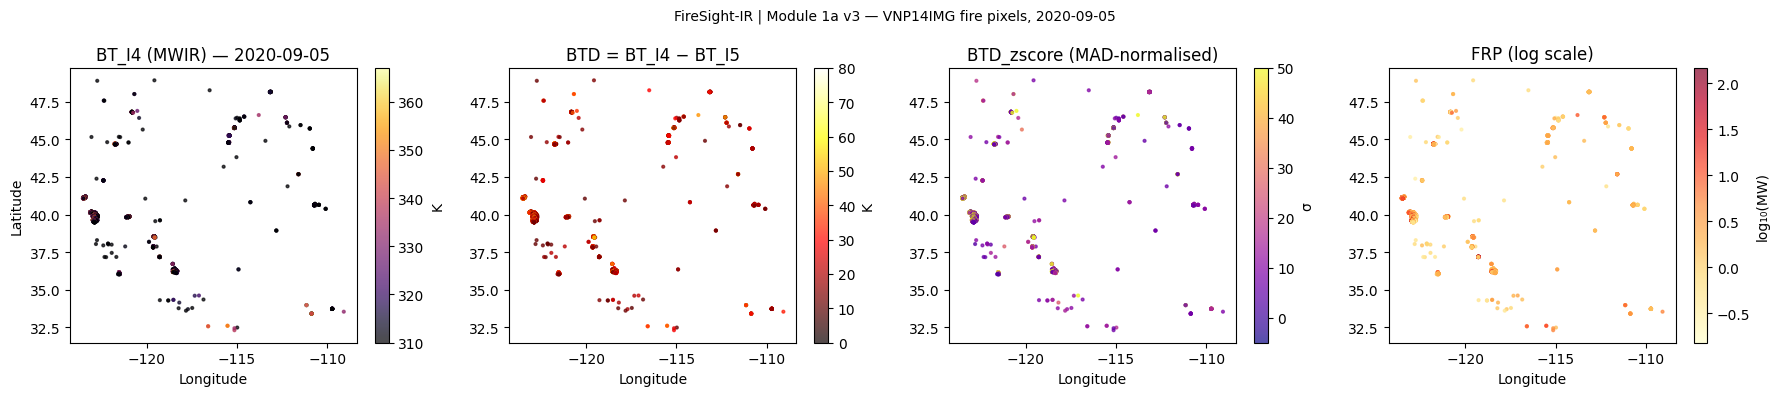

✓ Figure saved to Drive


In [26]:
if test_frames:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    sc0 = axes[0].scatter(test_df['longitude'], test_df['latitude'],
                          c=test_df['BT_I4'], cmap='inferno', s=4, alpha=0.7, vmin=310, vmax=367)
    plt.colorbar(sc0, ax=axes[0], label='K')
    axes[0].set_title(f'BT_I4 (MWIR) — {TEST_DATE}')
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

    sc1 = axes[1].scatter(test_df['longitude'], test_df['latitude'],
                          c=test_df['BTD'], cmap='hot', s=4, alpha=0.7, vmin=0, vmax=80)
    plt.colorbar(sc1, ax=axes[1], label='K')
    axes[1].set_title('BTD = BT_I4 − BT_I5')
    axes[1].set_xlabel('Longitude')

    sc2 = axes[2].scatter(test_df['longitude'], test_df['latitude'],
                          c=test_df['BTD_zscore'].clip(-5, 50), cmap='plasma', s=4, alpha=0.7)
    plt.colorbar(sc2, ax=axes[2], label='σ')
    axes[2].set_title('BTD_zscore (MAD-normalised)')
    axes[2].set_xlabel('Longitude')

    sc3 = axes[3].scatter(test_df['longitude'], test_df['latitude'],
                          c=np.log10(test_df['frp_mw'].clip(0.1)), cmap='YlOrRd', s=4, alpha=0.7)
    plt.colorbar(sc3, ax=axes[3], label='log₁₀(MW)')
    axes[3].set_title('FRP (log scale)')
    axes[3].set_xlabel('Longitude')

    fig.suptitle(f'FireSight-IR | Module 1a v3 — VNP14IMG fire pixels, {TEST_DATE}', fontsize=10)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01a_test_day_fire_pixels_v3.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure saved to Drive")

---
## Section 10 — Full batch processor

Processes all VIIRS granules for active fire days across 2018–2023.

**Deduplication key:** `['latitude', 'longitude', 'granule_id']` — removes intra-granule  
swath duplicates while preserving legitimate multi-overpass observations (same lat/lon,  
different granule, different time-of-day).

**Runtime:** ~90–120 minutes total. 2020 and 2021 are the largest years.  
**On Colab disconnect:** Reconnect, rerun Sections 0–3 and 6, then rerun this cell. Completed years skip automatically.

In [27]:
def process_year(
    year: int,
    firms_dir: Path,
    output_dir: Path,
    bbox_dict: dict,
    bbox_tuple: tuple,
    short_name: str,
    version: str,
    fp_vars: dict,
    fp_fill: dict,
    min_firms_count: int = 10,
    granule_batch_size: int = 5,
) -> dict:
    """
    Process all active fire days for a single year.

    For each active fire day:
      1. Query CMR for VNP14IMG granules
      2. Open granules from S3 in batches (FIX B: list-based open)
      3. Extract fire pixel records
      4. Concatenate, deduplicate, write annual parquet

    Deduplication key: ['latitude', 'longitude', 'granule_id']
    Removes intra-granule swath duplicates while preserving multi-overpass detections.

    Returns dict: year, n_pixels, n_days, n_errors, n_unknown_dt
    """
    out_path = output_dir / f'viirs_fp_{year}.parquet'

    if out_path.exists():
        df_existing = pd.read_parquet(out_path)
        print(f"  {year}: {len(df_existing):>9,} pixels  [on Drive — skipped]")
        return {'year': year, 'n_pixels': len(df_existing),
                'n_days': -1, 'n_errors': 0, 'n_unknown_dt': 0}

    active_days = get_active_fire_days(year, firms_dir, min_firms_count)
    if not active_days:
        print(f"  {year}: no active fire days found")
        return {'year': year, 'n_pixels': 0,
                'n_days': 0, 'n_errors': 0, 'n_unknown_dt': 0}

    year_frames = []
    n_errors    = 0

    for day_str in tqdm(active_days, desc=f'{year}', unit='day', leave=False):
        try:
            day_granules = earthaccess.search_data(
                short_name=short_name, version=version,
                temporal=(day_str, day_str),
                bounding_box=bbox_tuple,
                count=50,
            )
            if not day_granules:
                continue

            # FIX B: list-based open — no context manager on earthaccess.open()
            for i in range(0, len(day_granules), granule_batch_size):
                batch = day_granules[i:i + granule_batch_size]
                fhs = earthaccess.open(batch)
                for granule, fh in zip(batch, fhs):
                    try:
                        df = extract_granule_fp(
                            fh, granule, bbox_dict, fp_vars, fp_fill
                        )
                        if len(df) > 0:
                            year_frames.append(df)
                    except Exception as e:
                        n_errors += 1
                        if n_errors <= 3:
                            print(f"  [WARN] granule error on {day_str}: {e}")

        except Exception as day_err:
            n_errors += 1
            if n_errors <= 3:
                print(f"  [WARN] day error {day_str}: {day_err}")

    if not year_frames:
        print(f"  {year}: no fire pixels extracted")
        return {'year': year, 'n_pixels': 0,
                'n_days': len(active_days), 'n_errors': n_errors, 'n_unknown_dt': 0}

    year_df = pd.concat(year_frames, ignore_index=True)

    # Dedup: remove intra-granule swath duplicates; preserve multi-overpass rows
    year_df = year_df.drop_duplicates(subset=['latitude', 'longitude', 'granule_id'])

    n_unknown_dt = int((year_df['datetime_utc'] == 'unknown').sum())
    if n_unknown_dt > 0:
        print(
            f"  [WARN] {year}: {n_unknown_dt} pixels have datetime_utc='unknown' — "
            f"will be excluded from ERA5 co-location in Module 1b"
        )

    year_df.to_parquet(out_path, index=False)
    return {
        'year': year, 'n_pixels': len(year_df),
        'n_days': len(active_days), 'n_errors': n_errors,
        'n_unknown_dt': n_unknown_dt,
    }


print("✓ process_year() defined")
print("  earthaccess.open() called as list, not context manager  (FIX B)")
print("  Deduplication key: ['latitude', 'longitude', 'granule_id']")
print("  Batch size: 5 granules per S3 open call")

✓ process_year() defined
  earthaccess.open() called as list, not context manager  (FIX B)
  Deduplication key: ['latitude', 'longitude', 'granule_id']
  Batch size: 5 granules per S3 open call


In [1]:
# ── Run full extraction — 2018 to 2023 ────────────────────────────────────────
# ~90–120 minutes total. Stalled progress bars during S3 retries are normal.
# Do not interrupt. Completed years are skipped on rerun.

extraction_log = []

for year in ALL_YEARS:
    flag = ' ← VAL YEAR' if year == VAL_YEAR else ''
    print(f"\n── {year}{flag} ──")
    summary = process_year(
        year=year, firms_dir=FIRMS_DIR, output_dir=VIIRS_DIR,
        bbox_dict=BBOX_DICT, bbox_tuple=BBOX_TUPLE,
        short_name=VIIRS_SHORT_NAME, version=VIIRS_VERSION,
        fp_vars=FP_VARS, fp_fill=FP_FILL,
        min_firms_count=MIN_FIRMS_COUNT,
    )
    extraction_log.append(summary)
    if summary['n_days'] != -1:
        print(
            f"  {year}: {summary['n_pixels']:>9,} fire pixels | "
            f"{summary['n_days']} active days | "
            f"{summary['n_errors']} errors | "
            f"{summary['n_unknown_dt']} unknown-datetime rows"
        )

print("\n✓ Full extraction complete")

NameError: name 'ALL_YEARS' is not defined

---
## Section 11 — Output verification

In [ ]:
print("═══ FireSight-IR Module 1a v3 — Output Verification ═══\n")

EXPECTED_PIXELS = {
    2018: (150_000, 250_000),
    2019: (40_000,  90_000),
    2020: (250_000, 450_000),
    2021: (250_000, 450_000),
    2022: (60_000,  150_000),
    2023: (40_000,  130_000),
}

print(f"{'Year':<8} {'Pixels':>12} {'Status':<10} {'Expected range':<25} {'Note'}")
print('─' * 80)

pixel_counts = {}
for yr in ALL_YEARS:
    path = VIIRS_DIR / f'viirs_fp_{yr}.parquet'
    if not path.exists():
        print(f"{yr:<8} {'MISSING':>12} {'FAIL':<10}")
        continue

    df   = pd.read_parquet(path)
    cols = set(df.columns)
    n    = len(df)
    pixel_counts[yr] = n
    lo, hi = EXPECTED_PIXELS.get(yr, (0, 9e9))
    ok   = 'PASS' if lo <= n <= hi else 'CHECK'
    note = '← VAL YEAR' if yr == VAL_YEAR else ''
    print(f"{yr:<8} {n:>12,} {ok:<10} {lo:,} – {hi:,}        {note}")

    if yr == 2020:
        bt_ok   = df['BT_I4'].dropna().between(208, 367).mean()
        btd_ok  = (df['BTD'].dropna() > 15).mean()
        frp_ok  = df['frp_mw'].dropna().between(0.08, 2100).mean()
        sat_pct = (df['BT_I4'].dropna() >= 365).mean()

        if 'datetime_utc' in cols:
            unk_dt = (df['datetime_utc'] == 'unknown').mean()
            dt_str = f"{unk_dt*100:.2f}% (expect ~0%)"
        else:
            dt_str = "COLUMN MISSING — re-extract with v3"

        if 'BTD_zscore' in cols:
            zs = df['BTD_zscore'].dropna()
            zs_str = f"mean={zs.mean():.1f}  p95={zs.quantile(0.95):.1f}"
        else:
            zs_str = "COLUMN MISSING — re-extract with v3"

        print(f"  2020 range checks:")
        print(f"    BT_I4 in 208–367 K        : {bt_ok*100:.1f}%  (expect ~100%)")
        print(f"    BTD > 15 K (nominal conf) : {btd_ok*100:.1f}%  (expect >50%)")
        print(f"    FRP in range              : {frp_ok*100:.1f}%  (expect ~100%)")
        print(f"    BT_I4 saturated ≥365 K    : {sat_pct*100:.1f}%  (flag if >5%; Creek Fire expected)")
        print(f"    Unknown datetime_utc      : {dt_str}")
        print(f"    BTD_zscore                : {zs_str}")

# Total training pixels
total = sum(pixel_counts.get(yr, 0) for yr in TRAIN_YEARS)
print(f"\nTotal training pixels (2018–2022): {total:,}")
print(f"  {'PASS' if total > 1_000_000 else 'CHECK'} (expect >1,000,000)")

# Top-2 years check
if pixel_counts:
    top2 = sorted(pixel_counts, key=pixel_counts.get, reverse=True)[:2]
    print(f"\nTop 2 years by pixel count: {top2}")
    print(f"  {'PASS' if set(top2) <= {2020, 2021} else 'CHECK (unexpected)'}")

# File count
n_files = len(list(FIRMS_DIR.glob('*.parquet'))) + len(list(VIIRS_DIR.glob('*.parquet')))
print(f"\nParquet files on Drive: {n_files}  (expect 12 = 6 FIRMS + 6 VIIRS)")
print(f"  {'PASS' if n_files == 12 else f'CHECK — {n_files}/12 present'}")

In [ ]:
if pixel_counts:
    fig, ax = plt.subplots(figsize=(9, 4))
    years_x = list(pixel_counts.keys())
    counts  = list(pixel_counts.values())
    colors  = ['#A32D2D' if yr == VAL_YEAR else '#378ADD' for yr in years_x]

    bars = ax.bar(years_x, counts, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{n/1e3:.0f}k', ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Year')
    ax.set_ylabel('Fire pixels')
    ax.set_title(
        'FireSight-IR | Module 1a v3 — VNP14IMG fire pixels per year\n'
        'Blue = training | Red = validation (held out)'
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

    annotations = {
        2018: 'Camp Fire\nMendocino Complex',
        2020: 'Creek Fire\nAugust Complex\n(record season)',
        2021: 'Dixie Fire\nCaldor Fire',
    }
    for yr, label in annotations.items():
        if yr in pixel_counts:
            ax.annotate(label, xy=(yr, pixel_counts[yr]),
                       xytext=(yr, pixel_counts[yr] + max(counts)*0.06),
                       ha='center', fontsize=7.5, color='#333333',
                       arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01a_pixel_counts_v3.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure saved to Drive")

---
## Section 12 — FIRMS type column audit (label construction preview)

In [ ]:
print("FIRMS type column — label construction preview")
print("type=0: vegetation fire  → positive wildfire label")
print("type=2: static source    → false-alarm training (gas flares, industrial)")
print("type=3: offshore         → exclude from training")
print()

type_rows = []
for yr in ALL_YEARS:
    path = FIRMS_DIR / f'firms_viirs_snpp_{yr}.parquet'
    if not path.exists():
        continue
    df     = pd.read_parquet(path, columns=['type'])
    counts = df['type'].value_counts().to_dict()
    total  = len(df)
    type_rows.append({
        'year':    yr,
        'type_0':  counts.get(0, 0),
        'type_2':  counts.get(2, 0),
        'type_3':  counts.get(3, 0),
        'total':   total,
        'pct_veg': round(100 * counts.get(0, 0) / max(total, 1), 2),
    })

print(pd.DataFrame(type_rows).to_string(index=False))
total_type2 = sum(r['type_2'] for r in type_rows)
print(f"\nTotal type=2 detections (false-alarm pool): {total_type2:,}")
print('  Good — sufficient false-alarm training examples' if total_type2 > 1000
      else '  Low — supplement with DNB/OSM masks in Module 2')

---
## Section 13 — Summary

### v2 → v3 changes

| Fix | What changed | Why it matters |
|---|---|---|
| A | Removed `Fire Pixels/` prefix from all HDF5 paths | VNP14IMG v002 stores all FP arrays at root — old paths caused `PATH NOT FOUND` for every variable |
| B | `earthaccess.open()` called as list, not context manager | `with earthaccess.open(...) as fhs` raises `AttributeError` — list is not a context manager |
| C | Schema version check + stale-file deletion cell | v1/v2 parquets are missing `datetime_utc`, `BTD_zscore`, `granule_id` — Module 1b requires all three |
| D | `count_season_days()` uses actual calendar days | Old `len(months)*30` approximation gave negative skipped-day counts |

### Output column reference

| Column | Source | Description |
|---|---|---|
| `BT_I4`, `BT_I5` | VNP14IMG | Brightness temperature K — FireSat-analog MWIR/LWIR |
| `BT_I4_bg`, `BT_I5_bg` | VNP14IMG | Local background mean BT |
| `MAD_I4`, `MAD_I5` | VNP14IMG | Local background MAD |
| `MAD_DT` | VNP14IMG | Background delta-T MAD (new in v3) |
| `win_size` | VNP14IMG | Contextual window size (new in v3) |
| `adj_cloud` | VNP14IMG | Adjacent cloud pixels — cloud-proximity flag (new in v3) |
| `frp_mw` | VNP14IMG | Fire radiative power MW |
| `confidence` | VNP14IMG | 7=low / 8=nominal / 9=high |
| `sol_zen`, `view_zen` | VNP14IMG | Solar and view zenith angles |
| `BTD` | derived | BT_I4 − BT_I5 |
| `BT_I4_anom` | derived | BT_I4 − BT_I4_bg |
| `BTD_anom` | derived | BTD − BT_diff_bg |
| `BTD_zscore` | derived | (BTD − BT_diff_bg) / (MAD_I4 + ε) |
| `datetime_utc` | metadata | UTC timestamp — **required for Module 1b ERA5 co-location** |
| `date` | metadata | 'YYYY-MM-DD' |
| `granule_id` | metadata | Unique granule ID — used for deduplication |

### What comes next — Module 1b

Module 1b co-locates ERA5 atmospheric profiles with each fire pixel using `datetime_utc`  
and `latitude`/`longitude`. It retrieves temperature profile, specific humidity, and PBL height  
for Beer-Lambert transmittance inputs.

**Before Module 1b:** Register at https://cds.climate.copernicus.eu/ and install your CDS API key.